In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Veriyi yükle
df = pd.read_csv(r'C:\Users\Furkan Doğruyol\OneDrive\Masaüstü\ecommerce-forecasting\data\online_retail_II.csv', encoding='iso-8859-1')

print(f"Veri boyutu: {df.shape}")

Veri boyutu: (541910, 8)


In [4]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


In [5]:
# Veri boyutu
print(f"Toplam satır: {df.shape[0]:,}")
print(f"Toplam sütun: {df.shape[1]}")
print(f"\nSütun adları:")
print(df.columns.tolist())

Toplam satır: 541,910
Toplam sütun: 8

Sütun adları:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


In [6]:
print(df.isnull().sum())
print("\nBoş değer yüzdesi:")
print((df.isnull().sum() / len(df) * 100).round(2))

Invoice             0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
Price               0
Customer ID    135080
Country             0
dtype: int64

Boş değer yüzdesi:
Invoice         0.00
StockCode       0.00
Description     0.27
Quantity        0.00
InvoiceDate     0.00
Price           0.00
Customer ID    24.93
Country         0.00
dtype: float64


In [7]:
print("=== VERİ TİPLERİ ===")
print(df.dtypes)

=== VERİ TİPLERİ ===
Invoice         object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
Price          float64
Customer ID    float64
Country         object
dtype: object


In [8]:
df.describe()

,Quantity,Price,Customer ID
count,541910.000000,541910.000000,406830.000000
mean,9.552234,4.611138,15287.684160
std,218.080957,96.759765,1713.603074
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [9]:
# Özet bilgi
print("=== ÖZETİ RAPOR ===")
print(f"Fiyat aralığı: {df['Price'].min():.2f} - {df['Price'].max():.2f}")
print(f"Ortalama fiyat: {df['Price'].mean():.2f}")
print(f"\nMiktar aralığı: {df['Quantity'].min()} - {df['Quantity'].max()}")
print(f"Ortalama miktar: {df['Quantity'].mean():.2f}")
print(f"\nKaç farklı müşteri: {df['Customer ID'].nunique()}")
print(f"Kaç farklı ürün: {df['StockCode'].nunique()}")
print(f"Kaç ülke: {df['Country'].nunique()}")

=== ÖZETİ RAPOR ===
Fiyat aralığı: -11062.06 - 38970.00
Ortalama fiyat: 4.61

Miktar aralığı: -80995 - 80995
Ortalama miktar: 9.55

Kaç farklı müşteri: 4372
Kaç farklı ürün: 4070
Kaç ülke: 38


In [10]:
# DATA CLEANING

In [11]:
df_original = df.copy()

print(f"Orijinal veri: {df_original.shape[0]:,} satır")

Orijinal veri: 541,910 satır


In [12]:
df = df.dropna(subset=['Customer ID'])

print(f"Customer ID boş olanlar silindi")
print(f"Veri: {df.shape[0]:,} satır (Silinen: {df_original.shape[0] - df.shape[0]:,})")

Customer ID boş olanlar silindi
Veri: 406,830 satır (Silinen: 135,080)


In [13]:
df = df.dropna(subset=['Description'])

print(f"Description boş olanlar silindi")
print(f"Veri: {df.shape[0]:,} satır")

Description boş olanlar silindi
Veri: 406,830 satır


In [14]:
print(f"\nNegatif fiyat satırları: {(df['Price'] < 0).sum()}")

df = df[df['Price'] > 0]

print(f"Veri: {df.shape[0]:,} satır")


Negatif fiyat satırları: 0
Veri: 406,790 satır


In [15]:
print(f"Negatif miktar satırları: {(df['Quantity'] < 0).sum()}")

df = df[df['Quantity'] > 0]

print(f"Veri: {df.shape[0]:,} satır")

Negatif miktar satırları: 8905
Veri: 397,885 satır


In [16]:
# InvoiceDate'i otomatik olarak tarih formatına çevir
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='mixed', dayfirst=True)

print(f"✅ InvoiceDate tarih formatına çevrildi")
print(f"\nTarih aralığı: {df['InvoiceDate'].min()} - {df['InvoiceDate'].max()}")

✅ InvoiceDate tarih formatına çevrildi

Tarih aralığı: 2010-01-12 08:26:00 - 2011-12-10 17:19:00


In [17]:
print("=== TEMİZ VERİ ===")
print(f"Toplam satır: {df.shape[0]:,}")
print(f"\nBoş değerler:")
print(df.isnull().sum())
print(f"\nFiyat aralığı: {df['Price'].min():.2f} - {df['Price'].max():.2f}")
print(f"Miktar aralığı: {df['Quantity'].min()} - {df['Quantity'].max()}")

=== TEMİZ VERİ ===
Toplam satır: 397,885

Boş değerler:
Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64

Fiyat aralığı: 0.00 - 8142.75
Miktar aralığı: 1 - 80995


In [18]:
# FEATURE ENGINEERING

In [19]:
df['Date'] = df['InvoiceDate'].dt.date

#  ciro
df['Sales'] = df['Quantity'] * df['Price']

print("✅ Günlük satış eklendi")
print(df[['Date', 'StockCode', 'Description', 'Quantity', 'Price', 'Sales']].head())

✅ Günlük satış eklendi
         Date StockCode                          Description  Quantity  Price  \
0  2010-01-12    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   2.55   
1  2010-01-12     71053                  WHITE METAL LANTERN         6   3.39   
2  2010-01-12    84406B       CREAM CUPID HEARTS COAT HANGER         8   2.75   
3  2010-01-12    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   3.39   
4  2010-01-12    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   3.39   

   Sales  
0  15.30  
1  20.34  
2  22.00  
3  20.34  
4  20.34  


In [20]:
product_daily = df.groupby(['Date', 'StockCode']).agg({
    'Quantity': 'sum',
    'Sales': 'sum',
    'Description': 'first'  # Ürün adı (ilk değer)
}).reset_index()

product_daily = product_daily.rename(columns={'Quantity': 'Daily_Quantity', 'Sales': 'Daily_Sales'})

print(f"✅ Ürün günlük satışları oluşturuldu")
print(f"Boyut: {product_daily.shape}")
print(product_daily.head())

✅ Ürün günlük satışları oluşturuldu
Boyut: (222370, 5)
         Date StockCode  Daily_Quantity  Daily_Sales  \
0  2010-01-12     10002              60        51.00   
1  2010-01-12     10125               2         1.70   
2  2010-01-12     10133               5         4.25   
3  2010-01-12    15044B               1         2.95   
4  2010-01-12   15056BL              20       113.00   

                    Description  
0   INFLATABLE POLITICAL GLOBE   
1       MINI FUNKY DESIGN TAPES  
2  COLOURING PENCILS BROWN TUBE  
3           BLUE PAPER PARASOL   
4       EDWARDIAN PARASOL BLACK  


In [21]:
# RFM = Recency, Frequency, Monetary
# Recency: Son satın alma kaç gün önceydi?
# Frequency: Kaç kez satın aldı?
# Monetary: Toplam ne kadar harcadı?

# Referans tarihi = en son tarih + 1 gün
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': 'max',  # Son satın alma tarihi
    'Invoice': 'nunique',   # Kaç kez satın aldı (fatura sayısı)
    'Sales': 'sum'          # Toplam harcama
}).rename(columns={
    'InvoiceDate': 'Last_Purchase',
    'Invoice': 'Frequency',
    'Sales': 'Monetary'
})

# Recency hesapla (gün cinsinden)
rfm['Recency'] = (reference_date - rfm['Last_Purchase']).dt.days

rfm = rfm[['Recency', 'Frequency', 'Monetary']]

print("✅ RFM ölçütleri hesaplandı")
print(rfm.describe().round(2))

✅ RFM ölçütleri hesaplandı
       Recency  Frequency   Monetary
count  4338.00    4338.00    4338.00
mean    106.47       4.27    2054.27
std     115.08       7.70    8989.23
min       1.00       1.00       3.75
25%      23.00       1.00     307.41
50%      62.00       2.00     674.48
75%     162.75       5.00    1661.74
max     698.00     209.00  280206.02


In [22]:
# Churn = Son 90 gün içinde satın alma yapmayanlar

# Son satın alma tarihi
last_purchase = df.groupby('Customer ID')['InvoiceDate'].max()

# Referans tarihten 90 gün önce
churn_threshold = reference_date - pd.Timedelta(days=90)

# Churn etiketini oluştur
rfm['Churn'] = (last_purchase < churn_threshold).astype(int)

print("✅ Churn etiketi oluşturuldu")
print(f"Churn müşteri sayısı: {rfm['Churn'].sum()}")
print(f"Aktif müşteri sayısı: {(rfm['Churn'] == 0).sum()}")
print(f"Churn oranı: {rfm['Churn'].mean() * 100:.2f}%")

✅ Churn etiketi oluşturuldu
Churn müşteri sayısı: 1713
Aktif müşteri sayısı: 2625
Churn oranı: 39.49%


In [23]:
print("=== HAZIRLIK TAMAMLANDI ===")
print(f"\n1️⃣ Ürün Günlük Satışları: {product_daily.shape[0]:,} satır")
print(f"   Zaman Aralığı: {product_daily['Date'].min()} - {product_daily['Date'].max()}")
print(f"\n2️⃣ RFM Müşteri Segmentasyonu: {rfm.shape[0]} müşteri")
print(f"   - Ortalama Recency: {rfm['Recency'].mean():.0f} gün")
print(f"   - Ortalama Frequency: {rfm['Frequency'].mean():.2f} satın alma")
print(f"   - Ortalama Monetary: ₺{rfm['Monetary'].mean():.2f}")
print(f"\n3️⃣ Churn Tahmini: %{rfm['Churn'].mean() * 100:.2f} kayıp müşteri")

=== HAZIRLIK TAMAMLANDI ===

1️⃣ Ürün Günlük Satışları: 222,370 satır
   Zaman Aralığı: 2010-01-12 - 2011-12-10

2️⃣ RFM Müşteri Segmentasyonu: 4338 müşteri
   - Ortalama Recency: 106 gün
   - Ortalama Frequency: 4.27 satın alma
   - Ortalama Monetary: ₺2054.27

3️⃣ Churn Tahmini: %39.49 kayıp müşteri


In [24]:
# RFM ANALYSIS

In [25]:
# Her ölçüt için 1-5 arası skor ver
# Recency: az gün = iyi = yüksek skor
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=5, labels=[5, 4, 3, 2, 1])

# Frequency: çok satın alma = iyi = yüksek skor
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])

# Monetary: çok harcama = iyi = yüksek skor
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=5, labels=[1, 2, 3, 4, 5])

# Toplam RFM skoru
rfm['RFM_Score'] = rfm['R_Score'].astype(int) + rfm['F_Score'].astype(int) + rfm['M_Score'].astype(int)

print("✅ RFM skorları hesaplandı")
print(rfm[['Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score']].head(10))

✅ RFM skorları hesaplandı
             Recency  Frequency  Monetary R_Score F_Score M_Score  RFM_Score
Customer ID                                                                 
12346.0          327          1  77183.60       1       1       5          7
12347.0           41          7   4310.00       4       5       5         14
12348.0           77          4   1797.24       3       4       4         11
12349.0           20          1   1757.55       4       1       4          9
12350.0          312          1    334.40       1       1       2          4
12352.0           74          8   2506.04       3       5       5         13
12353.0          205          1     89.00       1       1       1          3
12354.0          234          1   1079.40       1       1       4          6
12355.0           97          1    459.40       2       1       2          5
12356.0           24          3   2811.43       4       3       5         12


In [26]:
# RFM skoruna göre segment ata
def assign_segment(score):
    if score >= 13:
        return 'Şampiyonlar'       # En iyi müşteriler
    elif score >= 10:
        return 'Sadık Müşteriler'  # Sık satın alan
    elif score >= 7:
        return 'Risk Altında'      # Eskiden iyiydi, azaldı
    else:
        return 'Kayıp Müşteriler'  # Uzun süredir yok

rfm['Segment'] = rfm['RFM_Score'].apply(assign_segment)

print("✅ Segmentler oluşturuldu")
print("\nSegment dağılımı:")
print(rfm['Segment'].value_counts())
print("\nYüzdeler:")
print((rfm['Segment'].value_counts() / len(rfm) * 100).round(2))

✅ Segmentler oluşturuldu

Segment dağılımı:
Segment
Kayıp Müşteriler    1301
Risk Altında        1096
Sadık Müşteriler     992
Şampiyonlar          949
Name: count, dtype: int64

Yüzdeler:
Segment
Kayıp Müşteriler    29.99
Risk Altında        25.27
Sadık Müşteriler    22.87
Şampiyonlar         21.88
Name: count, dtype: float64


In [27]:
# Her segmentin ortalaması
segment_profile = rfm.groupby('Segment').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'RFM_Score': 'count'
}).rename(columns={'RFM_Score': 'Müşteri Sayısı'}).round(2)

print("=== SEGMENT PROFİLLERİ ===")
print(segment_profile)

=== SEGMENT PROFİLLERİ ===
                  Recency  Frequency  Monetary  Müşteri Sayısı
Segment                                                       
Kayıp Müşteriler   217.40       1.13    281.29            1301
Risk Altında        98.16       2.01    732.03            1096
Sadık Müşteriler    52.80       3.89   1722.42             992
Şampiyonlar         20.10      11.60   6358.82             949


In [29]:
import os
os.makedirs('../output', exist_ok=True)
print("✅ output klasörü oluşturuldu!")

✅ output klasörü oluşturuldu!


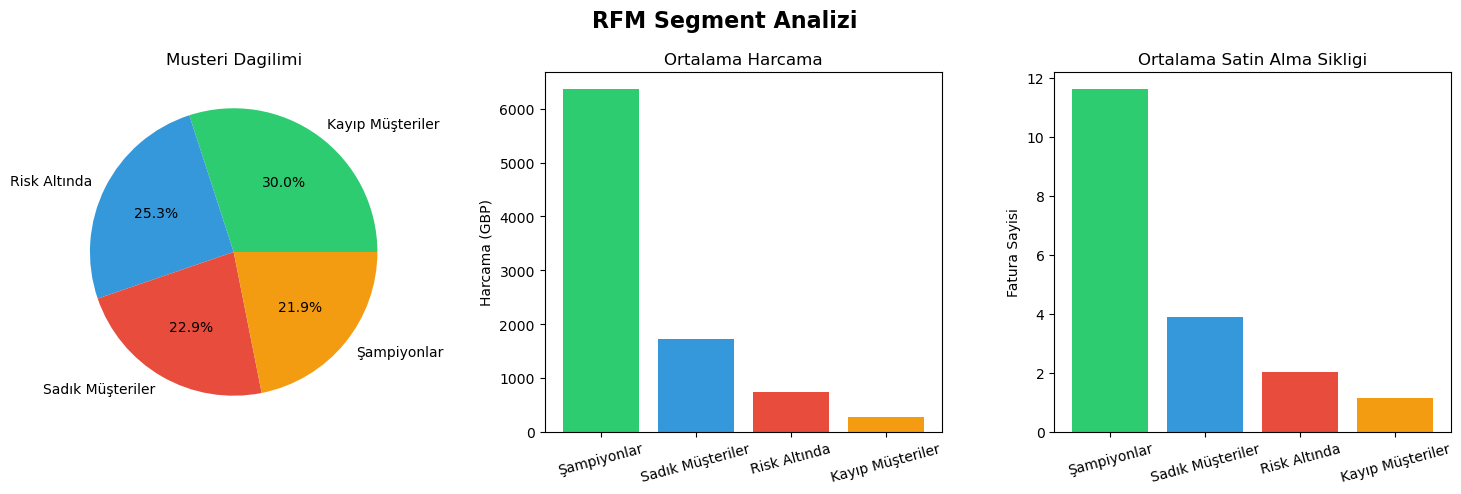

✅ Grafik kaydedildi: output/rfm_segments.png


In [30]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('RFM Segment Analizi', fontsize=16, fontweight='bold')

colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']
segment_counts = rfm['Segment'].value_counts()

# 1. Müşteri Sayısı (Pasta Grafik)
axes[0].pie(segment_counts.values, 
            labels=segment_counts.index, 
            autopct='%1.1f%%', 
            colors=colors)
axes[0].set_title('Musteri Dagilimi')

# 2. Ortalama Harcama (Bar Grafik)
segment_monetary = rfm.groupby('Segment')['Monetary'].mean().sort_values(ascending=False)
axes[1].bar(segment_monetary.index, segment_monetary.values, color=colors)
axes[1].set_title('Ortalama Harcama')
axes[1].set_ylabel('Harcama (GBP)')
axes[1].tick_params(axis='x', rotation=15)

# 3. Ortalama Satin Alma Sikligi (Bar Grafik)
segment_freq = rfm.groupby('Segment')['Frequency'].mean().sort_values(ascending=False)
axes[2].bar(segment_freq.index, segment_freq.values, color=colors)
axes[2].set_title('Ortalama Satin Alma Sikligi')
axes[2].set_ylabel('Fatura Sayisi')
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('../output/rfm_segments.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Grafik kaydedildi: output/rfm_segments.png")

In [31]:
# RFM verisini kaydet (sonra kullanacağız)
rfm.to_csv('../data/rfm_data.csv')

print("✅ RFM verisi kaydedildi: data/rfm_data.csv")
print(f"\nToplam müşteri: {len(rfm)}")
print(f"\nSegment özeti:")
print(rfm['Segment'].value_counts())

✅ RFM verisi kaydedildi: data/rfm_data.csv

Toplam müşteri: 4338

Segment özeti:
Segment
Kayıp Müşteriler    1301
Risk Altında        1096
Sadık Müşteriler     992
Şampiyonlar          949
Name: count, dtype: int64


In [32]:
# CHURN TAHMINI

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import xgboost as xgb

# Özellikler ve hedef değişken
X = rfm[['Recency', 'Frequency', 'Monetary']]
y = rfm['Churn']

# Eğitim ve test olarak böl (%80 eğitim, %20 test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("✅ Veri bölündü")
print(f"Eğitim seti: {X_train.shape[0]} müşteri")
print(f"Test seti: {X_test.shape[0]} müşteri")

✅ Veri bölündü
Eğitim seti: 3470 müşteri
Test seti: 868 müşteri


In [44]:
X = rfm[['Frequency', 'Monetary']]
y = rfm['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model2 = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

model2.fit(X_train, y_train)
y_pred2 = model2.predict(X_test)

print("=== MODEL SONUÇLARI ===")
print(classification_report(y_test, y_pred2,
      target_names=['Aktif', 'Churn']))

=== MODEL SONUÇLARI ===
              precision    recall  f1-score   support

       Aktif       0.75      0.77      0.76       519
       Churn       0.64      0.61      0.62       349

    accuracy                           0.70       868
   macro avg       0.69      0.69      0.69       868
weighted avg       0.70      0.70      0.70       868



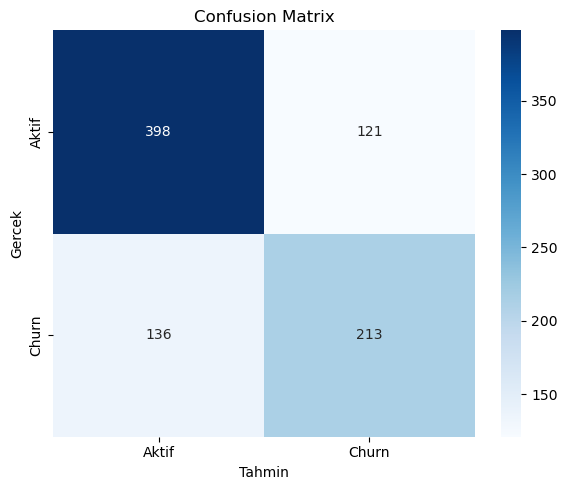

✅ Grafik kaydedildi!


In [47]:
cm = confusion_matrix(y_test, y_pred2)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Aktif', 'Churn'],
            yticklabels=['Aktif', 'Churn'])
plt.title('Confusion Matrix')
plt.ylabel('Gercek')
plt.xlabel('Tahmin')
plt.tight_layout()
plt.savefig('../output/churn_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Grafik kaydedildi!")

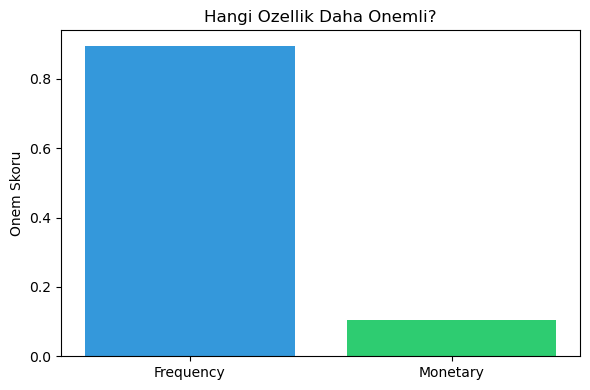


Özellik Önem Sırası:
     Ozellik      Onem
0  Frequency  0.895129
1   Monetary  0.104871


In [48]:
importance = pd.DataFrame({
    'Ozellik': ['Frequency', 'Monetary'],
    'Onem': model2.feature_importances_
}).sort_values('Onem', ascending=False)

plt.figure(figsize=(6, 4))
plt.bar(importance['Ozellik'], importance['Onem'], color=['#3498db', '#2ecc71'])
plt.title('Hangi Ozellik Daha Onemli?')
plt.ylabel('Onem Skoru')
plt.tight_layout()
plt.savefig('../output/churn_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nÖzellik Önem Sırası:")
print(importance)

In [49]:
# Her müşteri için churn olasılığı hesapla
rfm['Churn_Probability'] = model2.predict_proba(X)[:, 1]

print("✅ Churn olasılıkları hesaplandı")
print("\nEn yüksek churn riski taşıyan 10 müşteri:")
print(rfm.sort_values('Churn_Probability', ascending=False)[
    ['Recency', 'Frequency', 'Monetary', 'Segment', 'Churn_Probability']
].head(10).round(2))

✅ Churn olasılıkları hesaplandı

En yüksek churn riski taşıyan 10 müşteri:
             Recency  Frequency  Monetary           Segment  Churn_Probability
Customer ID                                                                   
13132.0          263          1     77.30  Kayıp Müşteriler               0.85
13106.0          135          1     76.50  Kayıp Müşteriler               0.85
16610.0          250          1     75.66  Kayıp Müşteriler               0.85
14373.0          360          1     76.55  Kayıp Müşteriler               0.85
17536.0          179          1     76.50  Kayıp Müşteriler               0.85
18113.0          547          1     76.32  Kayıp Müşteriler               0.85
13747.0          698          1     79.60  Kayıp Müşteriler               0.85
17752.0          361          1     80.64  Kayıp Müşteriler               0.85
15668.0          189          1     76.32  Kayıp Müşteriler               0.85
14090.0          326          1     76.32  Kayıp Müşteri

In [50]:
# Güncel rfm verisini kaydet
rfm.to_csv('../data/rfm_churn_data.csv')

print("✅ Veri kaydedildi: data/rfm_churn_data.csv")

✅ Veri kaydedildi: data/rfm_churn_data.csv


In [51]:
# LSTM SATIS TAHMINI

In [52]:
# En çok satan 10 ürün
top_products = product_daily.groupby(['StockCode', 'Description'])['Daily_Quantity'].sum()
top_products = top_products.sort_values(ascending=False).head(10)

print("=== EN ÇOK SATAN 10 ÜRÜN ===")
print(top_products)

=== EN ÇOK SATAN 10 ÜRÜN ===
StockCode  Description                       
23843      PAPER CRAFT , LITTLE BIRDIE           80995
23166      MEDIUM CERAMIC TOP STORAGE JAR        77916
84077      WORLD WAR 2 GLIDERS ASSTD DESIGNS     54415
85099B     JUMBO BAG RED RETROSPOT               46181
85123A     WHITE HANGING HEART T-LIGHT HOLDER    36781
84879      ASSORTED COLOUR BIRD ORNAMENT         35362
21212      PACK OF 72 RETROSPOT CAKE CASES       33693
22197      POPCORN HOLDER                        30952
23084      RABBIT NIGHT LIGHT                    27202
22492      MINI PAINT SET VINTAGE                26076
Name: Daily_Quantity, dtype: int64


In [53]:
# En çok satan ürünü seç
top_stock_code = top_products.index[0][0]
top_description = top_products.index[0][1]

print(f"Seçilen ürün: {top_description} ({top_stock_code})")

# Bu ürünün günlük satışlarını al
product_ts = product_daily[product_daily['StockCode'] == top_stock_code][['Date', 'Daily_Quantity']].copy()
product_ts = product_ts.sort_values('Date')
product_ts = product_ts.set_index('Date')

# Eksik günleri sıfır ile doldur
product_ts.index = pd.to_datetime(product_ts.index)
product_ts = product_ts.resample('D').sum().fillna(0)

print(f"\nZaman serisi: {len(product_ts)} gün")
print(f"Tarih aralığı: {product_ts.index.min()} - {product_ts.index.max()}")
print(product_ts.head(10))

Seçilen ürün: PAPER CRAFT , LITTLE BIRDIE (23843)

Zaman serisi: 1 gün
Tarih aralığı: 2011-09-12 00:00:00 - 2011-09-12 00:00:00
            Daily_Quantity
Date                      
2011-09-12           80995


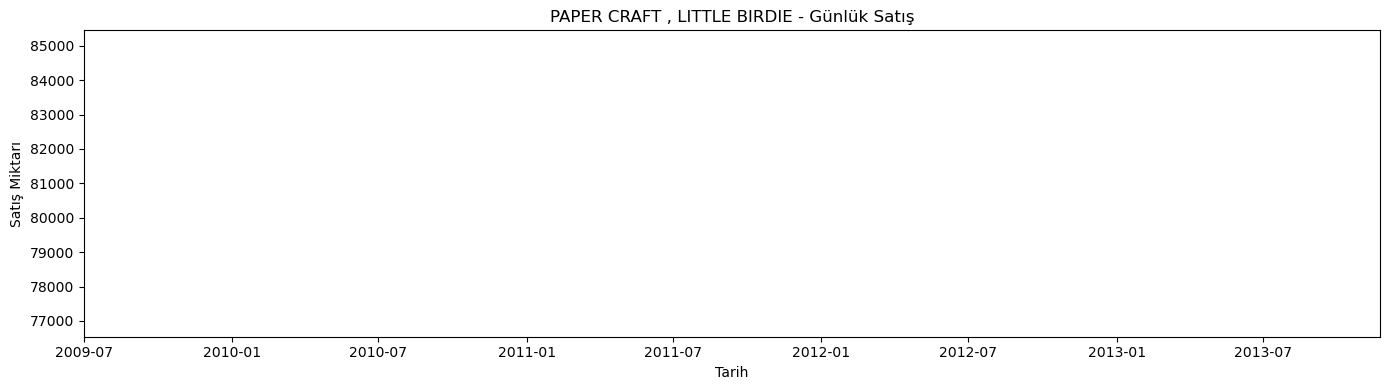

✅ Grafik kaydedildi!


In [54]:
plt.figure(figsize=(14, 4))
plt.plot(product_ts.index, product_ts['Daily_Quantity'], color='#3498db', linewidth=1)
plt.title(f'{top_description} - Günlük Satış')
plt.xlabel('Tarih')
plt.ylabel('Satış Miktarı')
plt.tight_layout()
plt.savefig('../output/lstm_product_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Grafik kaydedildi!")

In [55]:
# En az 100 farklı günde satılan ürünleri bul
product_day_count = product_daily.groupby('StockCode')['Date'].count()
frequent_products = product_day_count[product_day_count >= 100].index

# Bu ürünler arasından en çok satanı seç
top_frequent = product_daily[product_daily['StockCode'].isin(frequent_products)]
top_frequent = top_frequent.groupby(['StockCode', 'Description'])['Daily_Quantity'].sum()
top_frequent = top_frequent.sort_values(ascending=False).head(10)

print("=== DÜZENLI SATAN EN İYİ 10 ÜRÜN ===")
print(top_frequent)

=== DÜZENLI SATAN EN İYİ 10 ÜRÜN ===
StockCode  Description                       
23166      MEDIUM CERAMIC TOP STORAGE JAR        77916
84077      WORLD WAR 2 GLIDERS ASSTD DESIGNS     54415
85099B     JUMBO BAG RED RETROSPOT               46181
85123A     WHITE HANGING HEART T-LIGHT HOLDER    36781
84879      ASSORTED COLOUR BIRD ORNAMENT         35362
21212      PACK OF 72 RETROSPOT CAKE CASES       33693
22197      POPCORN HOLDER                        30952
22492      MINI PAINT SET VINTAGE                26076
22616      PACK OF 12 LONDON TISSUES             25345
21977      PACK OF 60 PINK PAISLEY CAKE CASES    24264
Name: Daily_Quantity, dtype: int64


Seçilen ürün: MEDIUM CERAMIC TOP STORAGE JAR
Zaman serisi: 337 gün
Tarih aralığı: 2011-01-08 00:00:00 - 2011-12-10 00:00:00


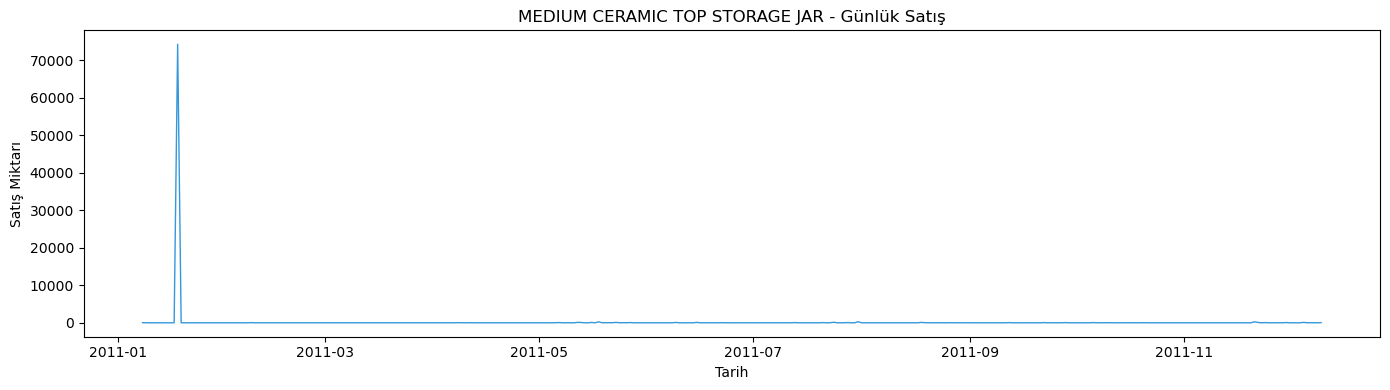

✅ Grafik kaydedildi!


In [56]:
# Yeni ürünü seç
top_stock_code = '23166'
top_description = 'MEDIUM CERAMIC TOP STORAGE JAR'

# Zaman serisi oluştur
product_ts = product_daily[product_daily['StockCode'] == top_stock_code][['Date', 'Daily_Quantity']].copy()
product_ts = product_ts.sort_values('Date')
product_ts = product_ts.set_index('Date')
product_ts.index = pd.to_datetime(product_ts.index)
product_ts = product_ts.resample('D').sum().fillna(0)

print(f"Seçilen ürün: {top_description}")
print(f"Zaman serisi: {len(product_ts)} gün")
print(f"Tarih aralığı: {product_ts.index.min()} - {product_ts.index.max()}")

# Grafik
plt.figure(figsize=(14, 4))
plt.plot(product_ts.index, product_ts['Daily_Quantity'], color='#3498db', linewidth=1)
plt.title(f'{top_description} - Günlük Satış')
plt.xlabel('Tarih')
plt.ylabel('Satış Miktarı')
plt.tight_layout()
plt.savefig('../output/lstm_product_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Grafik kaydedildi!")

Seçilen ürün: WHITE HANGING HEART T-LIGHT HOLDER
Zaman serisi: 698 gün
Günlük satış ortalaması: 44.1
Sıfır olan günler: 393


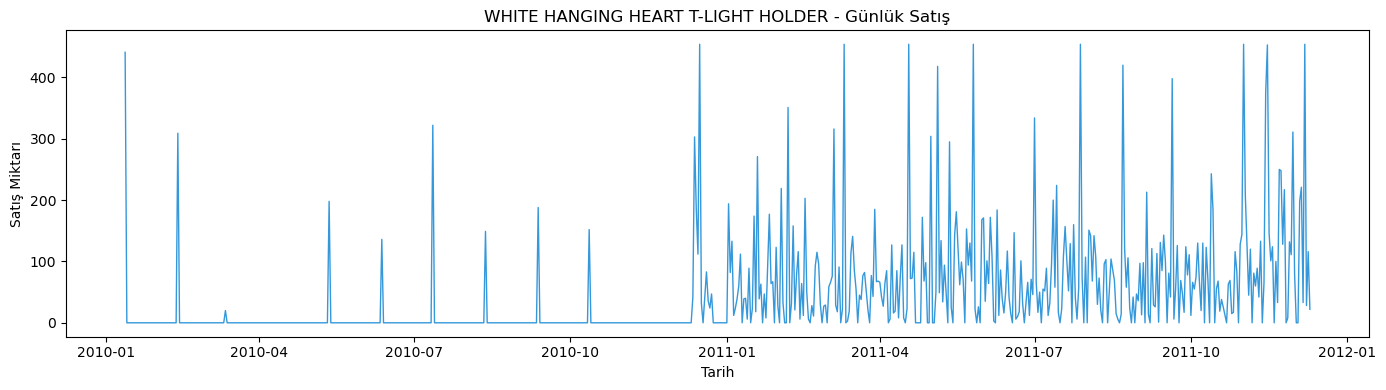

In [57]:
# Ürünü seç
top_stock_code = '85123A'
top_description = 'WHITE HANGING HEART T-LIGHT HOLDER'

# Zaman serisi oluştur
product_ts = product_daily[product_daily['StockCode'] == top_stock_code][['Date', 'Daily_Quantity']].copy()
product_ts = product_ts.sort_values('Date')
product_ts = product_ts.set_index('Date')
product_ts.index = pd.to_datetime(product_ts.index)
product_ts = product_ts.resample('D').sum().fillna(0)

# Outlier temizle (üst %1'i sınırla)
upper_limit = product_ts['Daily_Quantity'].quantile(0.99)
product_ts['Daily_Quantity'] = product_ts['Daily_Quantity'].clip(upper=upper_limit)

print(f"Seçilen ürün: {top_description}")
print(f"Zaman serisi: {len(product_ts)} gün")
print(f"Günlük satış ortalaması: {product_ts['Daily_Quantity'].mean():.1f}")
print(f"Sıfır olan günler: {(product_ts['Daily_Quantity'] == 0).sum()}")

# Grafik
plt.figure(figsize=(14, 4))
plt.plot(product_ts.index, product_ts['Daily_Quantity'], color='#3498db', linewidth=1)
plt.title(f'{top_description} - Günlük Satış')
plt.xlabel('Tarih')
plt.ylabel('Satış Miktarı')
plt.tight_layout()
plt.savefig('../output/lstm_product_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
import numpy as np

# Normalize et
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(product_ts[['Daily_Quantity']])

# Sequence oluştur (30 gün geriye bakarak 1 gün tahmin et)
SEQ_LEN = 30

def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, SEQ_LEN)

# %80 eğitim, %20 test
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# PyTorch tensor'a çevir
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
y_train = torch.FloatTensor(y_train)
y_test = torch.FloatTensor(y_test)

print(f"✅ Hazır!")
print(f"Eğitim: {X_train.shape}, Test: {X_test.shape}")